In [ ]:
!pip install --upgrade google-cloud-bigquery


In [ ]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery


project_id = "cmpe138sp25"
client = bigquery.Client(project=project_id)

print("Using project:", client.project)


Using project: cmpe138sp25


                date  NO2_concentration  temp  prcp city_name wind_speed  \
0         2018-01-01          23.165217  52.1  0.00  San Jose        8.6   
1         2018-01-01          23.165217  50.9  0.00  San Jose        9.7   
2         2018-01-01          23.165217  38.4  0.00  San Jose        3.9   
3         2018-01-01          23.165217  40.8  0.00  San Jose        7.3   
4         2018-01-01          23.165217  63.5  0.00  San Jose        0.7   
...              ...                ...   ...   ...       ...        ...   
34631343  2024-01-01          13.469565  54.3  0.12  San Jose        7.9   
34631344  2024-01-01          13.469565  30.4  0.14  San Jose      999.9   
34631345  2024-01-01          13.469565  24.3  0.00  San Jose        6.0   
34631346  2024-01-01          13.469565  78.0  0.04  San Jose        7.3   
34631347  2024-01-01          13.469565  72.5  0.00  San Jose        4.3   

          county_name  
0         Santa Clara  
1         Santa Clara  
2         Santa

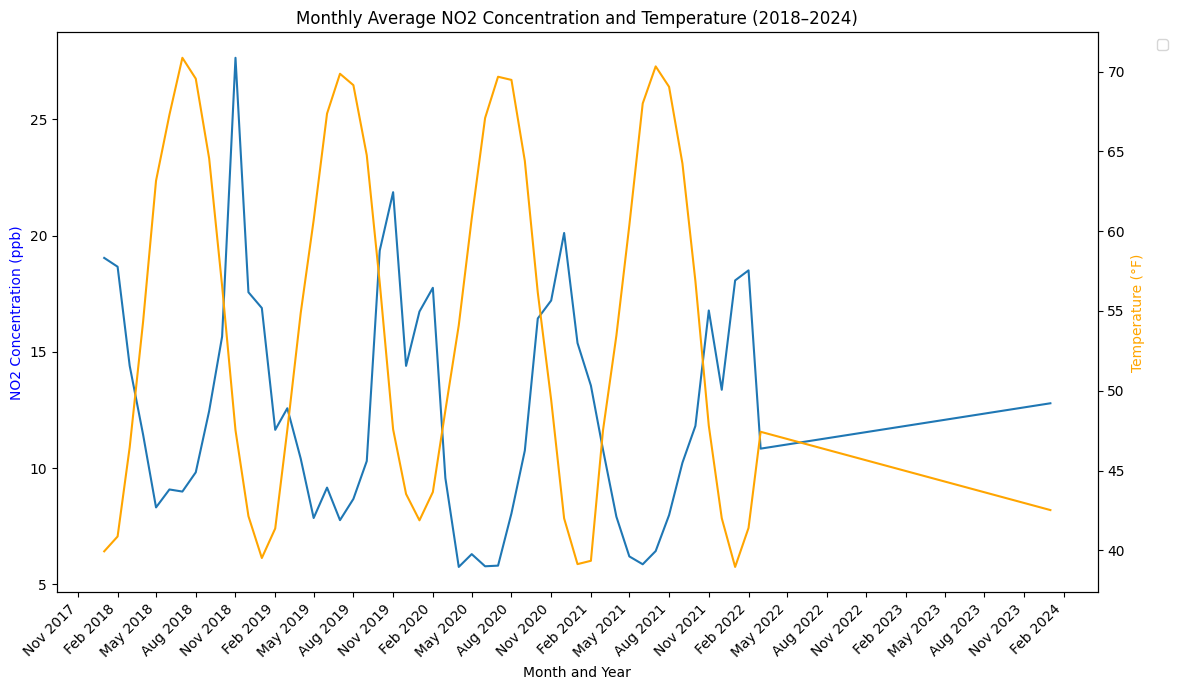

Pearson correlation between NO2 concentration and temperature: -0.698


In [ ]:
query_ahmed2_medOptimal = """
WITH weather_data AS (
  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2018`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'

  UNION ALL

  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2019`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'

  UNION ALL

  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2020`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'

  UNION ALL

  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2021`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'

  UNION ALL

  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2022`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'

  UNION ALL

  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2023`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'

  UNION ALL

  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod2024`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'
)


SELECT
  t1.date_local AS date,
  t1.arithmetic_mean AS NO2_concentration,
  t2.temp,
  t2.prcp,
  t2.wdsp AS wind_speed,
  t1.county_name,
FROM
  `bigquery-public-data.epa_historical_air_quality.no2_daily_summary` AS t1
LEFT JOIN weather_data AS t2
ON t1.date_local = DATE(CAST(t2.year AS INT64), CAST(t2.mo AS INT64), CAST(t2.da AS INT64))
WHERE
  t1.state_name = 'California'
  AND t1.county_name LIKE 'Santa Clara'
  AND t1.date_local BETWEEN '2018-01-01' AND '2024-01-01'
ORDER BY
  date ASC;
"""
query_optimized=  """
WITH weather_data AS (
  SELECT stn, wban, year, mo, da, temp, prcp, wdsp FROM `bigquery-public-data.noaa_gsod.gsod*`
    WHERE mo IS NOT NULL AND da IS NOT NULL
    AND DATE(CAST(year AS INT64), CAST(mo AS INT64), CAST(da AS INT64)) BETWEEN '2018-01-01' AND '2025-12-31'
)


SELECT
  t1.date_local AS date,
  t1.arithmetic_mean AS NO2_concentration,
  t2.temp,
  t2.prcp, t1.city_name,
  t2.wdsp AS wind_speed,
  t1.county_name,
FROM
  `bigquery-public-data.epa_historical_air_quality.no2_daily_summary` AS t1
LEFT JOIN weather_data AS t2
ON t1.date_local = DATE(CAST(t2.year AS INT64), CAST(t2.mo AS INT64), CAST(t2.da AS INT64))
WHERE
  t1.state_name = 'California'
  AND t1.county_name LIKE 'Santa Clara'
  AND t1.date_local BETWEEN '2018-01-01' AND '2024-01-01' AND t1.city_name = 'San Jose'
ORDER BY
  date ASC;
"""
query_ahmed2_unoptimized="""
                        SELECT
                          t1.date_local AS date,
                          t1.arithmetic_mean AS NO2_concentration,
                          t2.temp,
                          t2.prcp,
                          t1.city_name,
                          t2.wdsp AS wind_speed,
                          t1.county_name,
                          s.name AS station_name
                        FROM
                          `bigquery-public-data.epa_historical_air_quality.no2_daily_summary` AS t1
                        LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2018` AS t2
                        ON t1.date_local = DATE(CAST(t2.year AS INT64), CAST(t2.mo AS INT64), CAST(t2.da AS INT64))

                        LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2019` AS t3
                        ON t1.date_local = DATE(CAST(t3.year AS INT64), CAST(t3.mo AS INT64), CAST(t3.da AS INT64))

                       LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2020` AS t4
                        ON t1.date_local = DATE(CAST(t4.year AS INT64), CAST(t4.mo AS INT64), CAST(t4.da AS INT64))

                       LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2021` AS t5
                        ON t1.date_local = DATE(CAST(t5.year AS INT64), CAST(t5.mo AS INT64), CAST(t5.da AS INT64))

                       LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2022` AS t6
                        ON t1.date_local = DATE(CAST(t6.year AS INT64), CAST(t6.mo AS INT64), CAST(t6.da AS INT64))

                       LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2023` AS t7
                        ON t1.date_local = DATE(CAST(t7.year AS INT64), CAST(t7.mo AS INT64), CAST(t7.da AS INT64))

                       LEFT JOIN  `bigquery-public-data.noaa_gsod.gsod2024` AS t8
                        ON t1.date_local = DATE(CAST(t8.year AS INT64), CAST(t8.mo AS INT64), CAST(t8.da AS INT64))


                        LEFT JOIN
                          `bigquery-public-data.noaa_gsod.stations` AS s
                        ON
                          t2.stn = s.usaf AND t2.wban = s.wban AND  t3.stn = s.usaf AND t3.wban = s.wban AND  t4.stn = s.usaf AND t4.wban = s.wban AND  t5.stn = s.usaf AND t5.wban = s.wban AND  t6.stn = s.usaf AND t6.wban = s.wban AND  t7.stn = s.usaf AND t7.wban = s.wban AND  t8.stn = s.usaf AND t8.wban = s.wban
                          AND s.state = 'CA'
                          AND s.name LIKE 'SAN JOSE%'
                        WHERE
                          t1.state_name = 'California'
                          AND t1.county_name LIKE 'Santa Clara'
                          AND t1.date_local BETWEEN '2018-01-01' AND '2024-01-01'
                        ORDER BY
                          date ASC;


"""
query_job = client.query(query_optimized)
results1 = query_job.result().to_dataframe()

print(results1)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.dates as mdates

# Ensure 'date' column is datetime
results1['date'] = pd.to_datetime(results1['date'])

# Extract month for grouping
results1['month'] = results1['date'].dt.to_period('M')

# Group by month and compute averages
monthly_avg = results1.groupby('month').agg({
    'NO2_concentration': 'mean',
    'temp': 'mean'
}).reset_index()

# Convert Period to datetime for plotting
monthly_avg['month'] = monthly_avg['month'].dt.to_timestamp()

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(14, 7))

# Set x-axis formatting BEFORE plotting
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Plot NO2 on left y-axis
sns.lineplot(data=monthly_avg, x='month', y='NO2_concentration', ax=ax1)
ax1.set_xlabel('Month and Year')
ax1.set_ylabel('NO2 Concentration (ppb)', color='blue')

# Create right y-axis and plot temperature
ax2 = ax1.twinx()
sns.lineplot(data=monthly_avg, x='month', y='temp', ax=ax2, color='orange')
ax2.set_ylabel('Temperature (°F)', color='orange')

# Improve x-axis tick visibility
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=10)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, bbox_to_anchor=(1.05, 1), loc='upper left')

# Title and layout
plt.title('Monthly Average NO2 Concentration and Temperature (2018–2024)')
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Make space for legend

plt.show()

# Calculate and print Pearson correlation
correlation = monthly_avg['NO2_concentration'].corr(monthly_avg['temp'])
print(f"Pearson correlation between NO2 concentration and temperature: {correlation:.3f}")


This query gives you a sample of California's daily weather data (temp, precipitation, wind) from NOAA GSOD for the first week of 2020—handy for early testing or visualizing trends before scaling up.

In [ ]:

query = """
SELECT
  s.state,
  s.name AS station_name,
  g.year,
  g.mo AS month,
  g.da AS day,
  DATE(CAST(g.year as INT64), CAST(g.mo as INT64), CAST(g.da as INT64)) AS date,
  g.temp,
  g.prcp,
  g.wdsp AS wind_speed
FROM
  `bigquery-public-data.noaa_gsod.gsod2020` AS g
JOIN
  `bigquery-public-data.noaa_gsod.stations` AS s
ON
  g.stn = s.usaf  # Changed g.station_number to g.stn
  AND g.wban = s.wban # Changed g.wban_number to g.wban
WHERE
  s.state = 'CA'
  AND DATE(CAST(g.year as INT64), CAST(g.mo as INT64), CAST(g.da as INT64)) BETWEEN '2020-01-01' AND '2020-01-07'
LIMIT 10;
"""

query_job = client.query(query)
results1 = query_job.result().to_dataframe()

results1.head()

,state,station_name,year,month,day,date,temp,prcp,wind_speed
0,CA,EL MONTE AIRPORT,2020,01,02,2020-01-02,60.1,0.0,2.5
1,CA,BRACKETT FIELD AIRPORT,2020,01,05,2020-01-05,57.8,0.0,2.6
2,CA,BRACKETT FIELD AIRPORT,2020,01,02,2020-01-02,56.4,0.0,3.7
3,CA,ZAMPERINI FIELD AIRPORT,2020,01,02,2020-01-02,57.6,0.0,4.0
4,CA,BRACKETT FIELD AIRPORT,2020,01,01,2020-01-01,57.1,0.0,2.7


The purpose of this code is to extract and analyze historical daily weather data for the state of California from the NOAA Global Surface Summary of the Day (GSOD) dataset for a specific time period (January 1–7, 2020). By joining weather data with station metadata, the query helps identify:

In [ ]:
query = """
SELECT
  s.state,
  s.name AS station_name,
  g.year,
  g.mo AS month,
  g.da AS day,
  DATE(CAST(g.year as INT64), CAST(g.mo as INT64), CAST(g.da as INT64)) AS date,
  g.temp,
  g.prcp,
  g.wdsp AS wind_speed
FROM
  `bigquery-public-data.noaa_gsod.gsod2020` AS g
JOIN
  `bigquery-public-data.noaa_gsod.stations` AS s
ON
  g.stn = s.usaf  # Changed g.station_number to g.stn
  AND g.wban = s.wban # Changed g.wban_number to g.wban
WHERE
  s.state = 'CA'
  AND DATE(CAST(g.year as INT64), CAST(g.mo as INT64), CAST(g.da as INT64)) BETWEEN '2020-01-01' AND '2020-01-07'
LIMIT 10
"""

query_job = client.query(query)
results1 = query_job.result().to_dataframe()

results1.head()

,state,station_name,year,month,day,date,temp,prcp,wind_speed
0,CA,EL MONTE AIRPORT,2020,01,02,2020-01-02,60.1,0.0,2.5
1,CA,BRACKETT FIELD AIRPORT,2020,01,05,2020-01-05,57.8,0.0,2.6
2,CA,BRACKETT FIELD AIRPORT,2020,01,02,2020-01-02,56.4,0.0,3.7
3,CA,ZAMPERINI FIELD AIRPORT,2020,01,02,2020-01-02,57.6,0.0,4.0
4,CA,BRACKETT FIELD AIRPORT,2020,01,01,2020-01-01,57.1,0.0,2.7


The purpose of this code is to combine air quality data (PM2.5) from the EPA dataset with weather data (temperature, precipitation, and wind speed) from the NOAA GSOD dataset, specifically for Santa Clara County and the San Jose weather station during the first week of January 2020.

In [ ]:
query1 = """
SELECT
  date_local AS date,
  arithmetic_mean AS pm25,
  county_name,
  CAST(NULL AS BIGNUMERIC) AS temp,
  CAST(NULL AS BIGNUMERIC) AS prcp,
  CAST(NULL AS BIGNUMERIC) AS wind_speed,
  CAST(NULL AS STRING) AS station_name
FROM
  `bigquery-public-data.epa_historical_air_quality.pm25_frm_daily_summary`
WHERE
  state_name = 'California'
  AND county_name LIKE 'Santa Clara'
  AND date_local BETWEEN '2020-01-01' AND '2020-01-07'
"""

query2 = """
SELECT
  DATE(CAST(g.year AS INT64), CAST(g.mo AS INT64), CAST(g.da AS INT64)) AS date,
  CAST(NULL AS BIGNUMERIC) AS pm25,
  CAST(NULL AS STRING) AS county_name,
  g.temp,
  g.prcp,
  CAST(g.wdsp AS BIGNUMERIC) AS wind_speed,
  s.name AS station_name
FROM
  `bigquery-public-data.noaa_gsod.gsod2020` AS g
JOIN
  `bigquery-public-data.noaa_gsod.stations` AS s
ON
  g.stn = s.usaf
  AND g.wban = s.wban
WHERE
  s.state = 'CA'
  AND s.name LIKE 'SAN JOSE%'
  AND DATE(CAST(g.year AS INT64), CAST(g.mo AS INT64), CAST(g.da AS INT64)) BETWEEN '2020-01-01' AND '2020-01-07'
"""

combined_query = f"""
SELECT
  t1.date_local AS date,
  t1.arithmetic_mean AS pm25,
  t2.temp,
  t2.prcp,
  t2.wdsp AS wind_speed,
  s.name AS station_name
FROM
  `bigquery-public-data.epa_historical_air_quality.pm25_frm_daily_summary` AS t1
LEFT JOIN
  `bigquery-public-data.noaa_gsod.gsod2020` AS t2
    ON t1.date_local = DATE(CAST(t2.year AS INT64), CAST(t2.mo AS INT64), CAST(t2.da AS INT64))
LEFT JOIN
  `bigquery-public-data.noaa_gsod.stations` AS s
    ON t2.stn = s.usaf AND t2.wban = s.wban
    AND s.state = 'CA'
    AND s.name LIKE 'SAN JOSE%'
WHERE
  t1.state_name = 'California'
  AND t1.county_name LIKE 'Santa Clara'
  AND t1.date_local BETWEEN '2018-01-01' AND '2025-01-01'

"""

query_job = client.query(combined_query)
results_combined = query_job.result().to_dataframe()


query_job = client.query(query1)
results_combined1 = query_job.result().to_dataframe()

query_job = client.query(query2)
results_combined2 = query_job.result().to_dataframe()

print(results_combined)


                date       pm25  temp   prcp wind_speed station_name
0         2020-11-01  31.500000  75.8   0.00        6.8         None
1         2020-11-01  31.500000  79.0   0.00        4.0         None
2         2020-11-01  31.500000  50.5   0.00        2.2         None
3         2020-11-01  31.500000  59.9   0.00        4.4         None
4         2020-11-01  31.500000  -3.1   0.00        0.9         None
...              ...        ...   ...    ...        ...          ...
25834772  2020-06-21   4.291667  77.0  99.99        1.5         None
25834773  2020-06-21   4.291667  71.5   0.00        6.0         None
25834774  2020-06-21   4.291667  71.5   0.00        3.0         None
25834775  2020-06-21   4.291667  66.0   0.00        7.9         None
25834776  2020-06-21   4.291667  36.7   0.59        1.6         None

[25834777 rows x 6 columns]


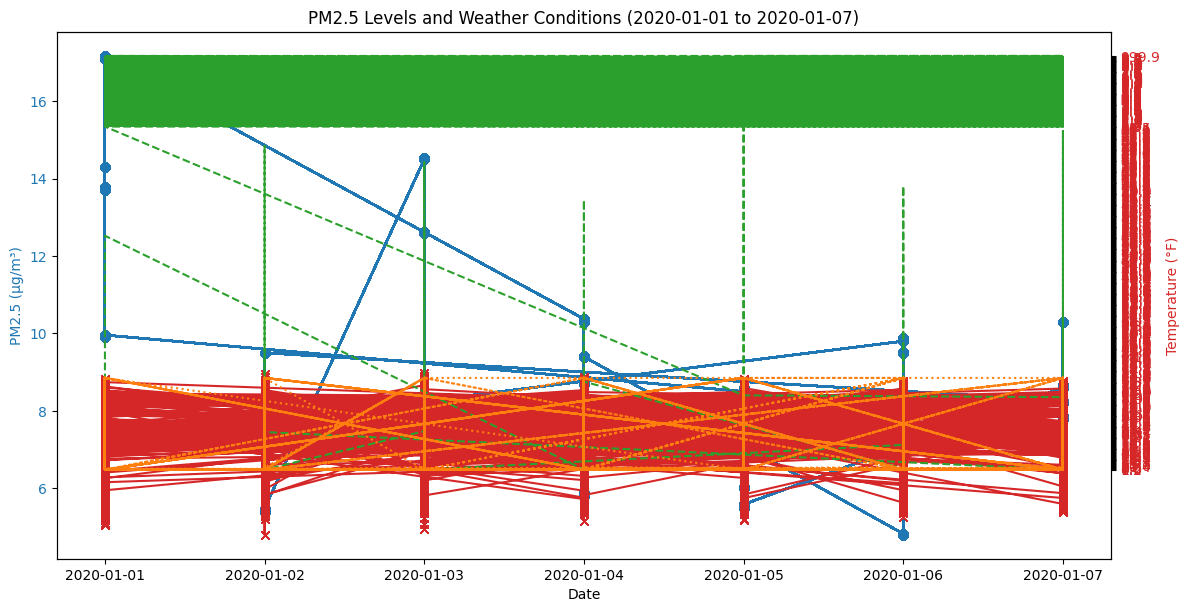

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming 'results_combined' is the dataframe
results_combined['date'] = pd.to_datetime(results_combined['date'])

# Create a figure with multiple subplots
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot PM2.5 levels
ax1.plot(results_combined['date'], results_combined['pm25'], color='tab:blue', label='PM2.5', marker='o')
ax1.set_xlabel('Date')
ax1.set_ylabel('PM2.5 (µg/m³)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second y-axis for temperature, precipitation, and wind speed
ax2 = ax1.twinx()
ax2.plot(results_combined['date'], results_combined['temp'], color='tab:red', label='Temperature (°F)', marker='x')
ax2.set_ylabel('Temperature (°F)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Plot wind speed and precipitation
ax2.plot(results_combined['date'], results_combined['wind_speed'], color='tab:green', label='Wind Speed (mph)', linestyle='--')
ax2.plot(results_combined['date'], results_combined['prcp'], color='tab:orange', label='Precipitation (inches)', linestyle=':')

# Add title and labels
fig.tight_layout()
plt.title('PM2.5 Levels and Weather Conditions (2020-01-01 to 2020-01-07)')
plt.xticks(rotation=45)
plt.show()


In [ ]:
query = """
SELECT
  t1.date_local AS date,
  t1.arithmetic_mean AS pm25,
  t2.temp,
  t2.prcp,
  t2.wdsp AS wind_speed,
  s.name AS station_name
FROM
  `bigquery-public-data.epa_historical_air_quality.pm25_frm_daily_summary` AS t1
LEFT JOIN
  `bigquery-public-data.noaa_gsod.gsod2020` AS t2
    ON t1.date_local = DATE(CAST(t2.year AS INT64), CAST(t2.mo AS INT64), CAST(t2.da AS INT64))
LEFT JOIN
  `bigquery-public-data.noaa_gsod.stations` AS s
    ON t2.stn = s.usaf AND t2.wban = s.wban
    AND s.state = 'CA'
    AND s.name LIKE 'SAN JOSE%'
WHERE
  t1.state_name = 'California'
  AND t1.county_name LIKE 'Santa Clara'
  AND t1.date_local BETWEEN '2020-01-01' AND '2020-01-07'
"""

df = client.query(query).result().to_dataframe()
# Print the entire DataFrame
print(df)

# preview
print(df.head())

              date  pm25  temp   prcp wind_speed station_name
0       2020-01-03  8.25  28.4   0.42       11.7         None
1       2020-01-03  8.25  68.3   0.00        8.9         None
2       2020-01-03  8.25  41.8   0.01       27.6         None
3       2020-01-03  8.25  22.3  99.99       12.8         None
4       2020-01-03  8.25  81.6   0.00        0.8         None
...            ...   ...   ...    ...        ...          ...
516763  2020-01-05  8.50  20.5   0.00      999.9         None
516764  2020-01-05  8.50  57.0   0.08      999.9         None
516765  2020-01-05  8.50  27.4   0.01      999.9         None
516766  2020-01-05  8.50  34.0   0.00      999.9         None
516767  2020-01-05  8.50  36.1  99.99      999.9         None

[516768 rows x 6 columns]
         date  pm25  temp   prcp wind_speed station_name
0  2020-01-03  8.25  28.4   0.42       11.7         None
1  2020-01-03  8.25  68.3   0.00        8.9         None
2  2020-01-03  8.25  41.8   0.01       27.6         None
3

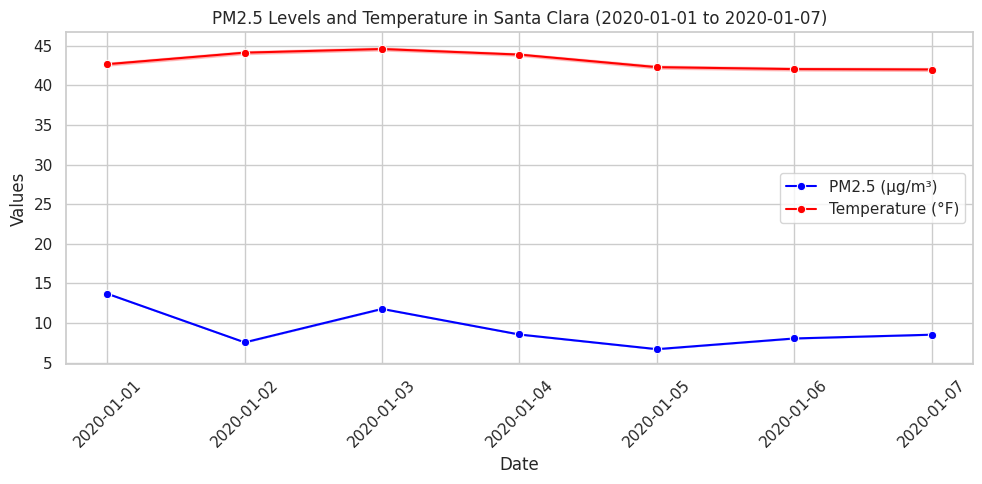

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Make sure 'date' is a datetime object
df['date'] = pd.to_datetime(df['date'])

#theme for the plots
sns.set(style="whitegrid")

# Multiple line graph for PM2.5 and Temperature
plt.figure(figsize=(10, 5))

# Plotting PM2.5
sns.lineplot(data=df, x='date', y='pm25', marker='o', label='PM2.5 (μg/m³)', color='blue')

# Plotting Temperature
sns.lineplot(data=df, x='date', y='temp', marker='o', label='Temperature (°F)', color='red')

# Titles and labels
plt.title('PM2.5 Levels and Temperature in Santa Clara (2020-01-01 to 2020-01-07)')
plt.xlabel('Date')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.tight_layout()

# Add legend
plt.legend()

# Show plot
plt.show()


In [ ]:
# Query the data
query = """
SELECT
  t1.date_local AS date,
  t1.arithmetic_mean AS pm25,
  t2.temp,
  t2.dewp,
  t2.prcp,
  t2.wdsp AS wind_speed,
  s.name AS station_name
FROM
  `bigquery-public-data.epa_historical_air_quality.pm25_frm_daily_summary` AS t1
LEFT JOIN
  `bigquery-public-data.noaa_gsod.gsod2020` AS t2
    ON t1.date_local = DATE(CAST(t2.year AS INT64), CAST(t2.mo AS INT64), CAST(t2.da AS INT64))
LEFT JOIN
  `bigquery-public-data.noaa_gsod.stations` AS s
    ON t2.stn = s.usaf AND t2.wban = s.wban
    AND s.state = 'CA'
    AND s.name LIKE 'SAN JOSE%'
WHERE
  t1.state_name = 'California'
  AND t1.county_name LIKE 'Santa Clara'
  AND t1.date_local BETWEEN '2020-01-01' AND '2020-02-01'
"""

# Run the query
df = client.query(query).result().to_dataframe()


# Step 2: Define the function
import numpy as np

#using dew ppint we can estimate the Humidity
def calculate_relative_humidity(temp_f, dewp_f):
    # Convert to Celsius
    temp_c = (temp_f - 32) * 5 / 9
    dewp_c = (dewp_f - 32) * 5 / 9
    return 100 * (np.exp((17.625 * dewp_c) / (243.04 + dewp_c)) /
                  np.exp((17.625 * temp_c) / (243.04 + temp_c)))

#  Calculate humidity and display
df['humidity'] = df.apply(lambda row: calculate_relative_humidity(row['temp'], row['dewp']), axis=1)

# Show humidity alongside PM2.5 and date
print(df[['date', 'pm25', 'humidity']])


               date      pm25      humidity
0        2020-01-12  7.916667  3.101576e+09
1        2020-01-12  7.916667  8.524545e+01
2        2020-01-12  7.916667  6.223858e+01
3        2020-01-12  7.916667  7.307139e+01
4        2020-01-12  7.916667  4.711675e+01
...             ...       ...           ...
2304892  2020-01-29  9.600000  8.663301e+08
2304893  2020-01-29  9.600000  2.133672e+09
2304894  2020-01-29  9.600000  6.742383e+01
2304895  2020-01-29  9.600000  7.984113e+01
2304896  2020-01-29  9.600000  9.789042e+01

[2304897 rows x 3 columns]
